<a href="https://colab.research.google.com/github/NguyenManhCuong1512/AI/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    StratifiedKFold, GridSearchCV
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier  # pip install xgboost

# Dataset dùng xuyên suốt
bc   = load_breast_cancer()   # nhị phân, 569 mẫu, 30 đặc trưng
iris = load_iris()            # 3 lớp,   150 mẫu,  4 đặc trưng
wine = load_wine()            # 3 lớp,   178 mẫu, 13 đặc trưng

X_bc, y_bc     = bc.data,   bc.target
X_iris, y_iris = iris.data, iris.target
X_wine, y_wine = wine.data, wine.target

Accuracy: 0.9667
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



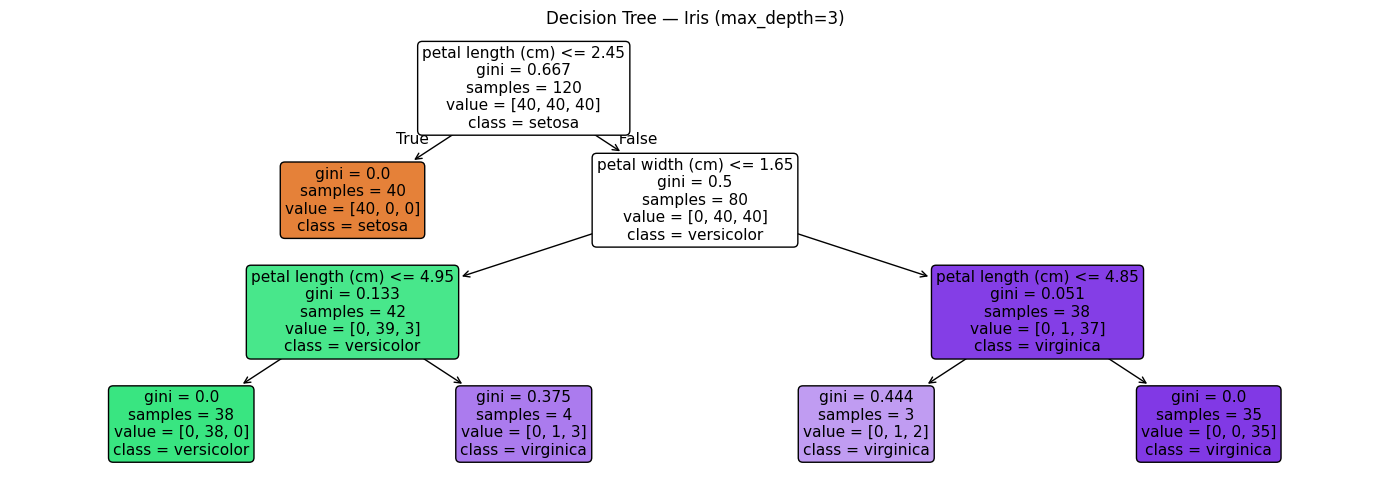

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, stratify=y_iris, random_state=42
)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

print(f"Accuracy: {clf.score(X_test, y_test):.4f}")
print(export_text(clf, feature_names=list(iris.feature_names)))

plt.figure(figsize=(14, 5))
plot_tree(clf, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree — Iris (max_depth=3)")
plt.tight_layout()
plt.show()

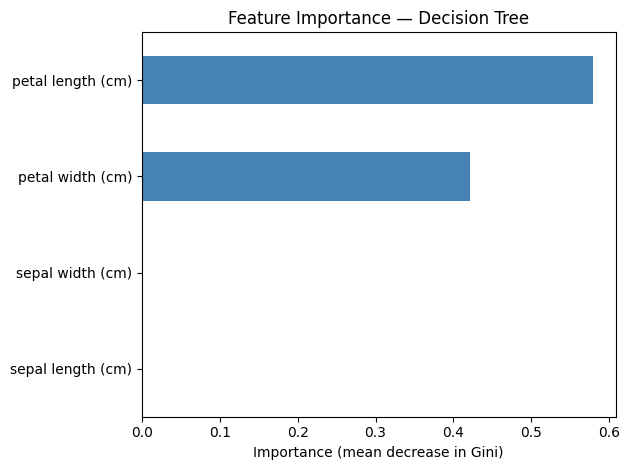

In [9]:
importance = pd.Series(clf.feature_importances_, index=iris.feature_names)
importance.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance (mean decrease in Gini)")
plt.tight_layout()
plt.show()

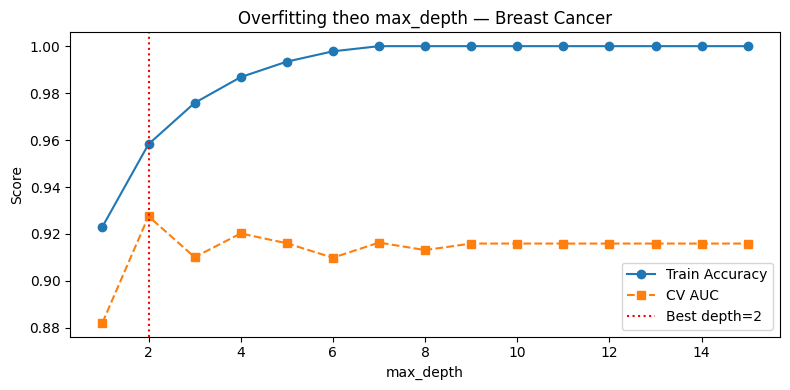

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42
)

depths = range(1, 16)
train_scores, val_scores = [], []

for d in depths:
    clf_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    val_scores.append(cross_val_score(clf_d, X_bc, y_bc, cv=5, scoring="roc_auc").mean())
    clf_d.fit(X_train, y_train)
    train_scores.append(clf_d.score(X_train, y_train))

best_d = depths[np.argmax(val_scores)]

plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, "o-", label="Train Accuracy")
plt.plot(depths, val_scores, "s--", label="CV AUC")
plt.axvline(x=best_d, color="red", linestyle=":", label=f"Best depth={best_d}")
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.legend()
plt.title("Overfitting theo max_depth — Breast Cancer")
plt.tight_layout()
plt.show()

Tham số tốt nhất: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}
AUC CV tốt nhất: 0.9658
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



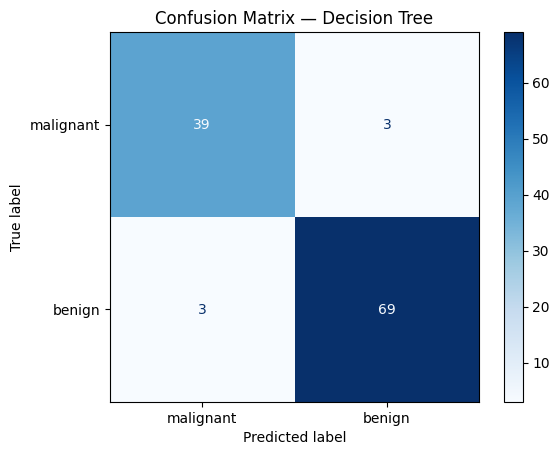

In [11]:
param_grid = {
    "max_depth":        [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion":        ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring="roc_auc", n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print("Tham số tốt nhất:", grid_dt.best_params_)
print(f"AUC CV tốt nhất: {grid_dt.best_score_:.4f}")

# Đánh giá cuối trên test set
best_dt = grid_dt.best_estimator_
best_dt.fit(X_train, y_train)
print(classification_report(y_test, best_dt.predict(X_test),
      target_names=bc.target_names))

ConfusionMatrixDisplay.from_estimator(
    best_dt, X_test, y_test, display_labels=bc.target_names, cmap="Blues"
)
plt.title("Confusion Matrix — Decision Tree")
plt.show()